In [3]:
# Synthetic data
import numpy as np
import matplotlib.pyplot as plt

We are generating data from the model
$$ f(t) = \sin(2\pi t) + \varepsilon $$
where $\varepsilon \sim \mathcal{N}(0,0.3^2)$.

In [35]:
np.random.seed(41)
n = 9
x = np.random.uniform(0, 1, size = n)
t = np.sin(2*np.pi*x) + np.random.normal(0, 0.3, size = n)

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

We want to fit a polynomial function on our (perturbed) sinusoidal data:
$$ y(x, \mathbf{x}) = \sum_{j=0}^M w_j x^j $$
where $M$ is the order of the polynomial, and $x_j$ denotes $x$ raised to the power of $j$. The values of the coefficients will be determined by fitting the polynomial to the
training data, which is done by minimizing an error function that measures the misfit between the function $y(x, \mathbf{w})$, for any given value of $\mathbf{x}$, and the training set data points $\mathbf{t} = (t_1,\dots,t_N)$:
$$ E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N [y(x_n, \mathbf{w}) - t_n]^2 $$

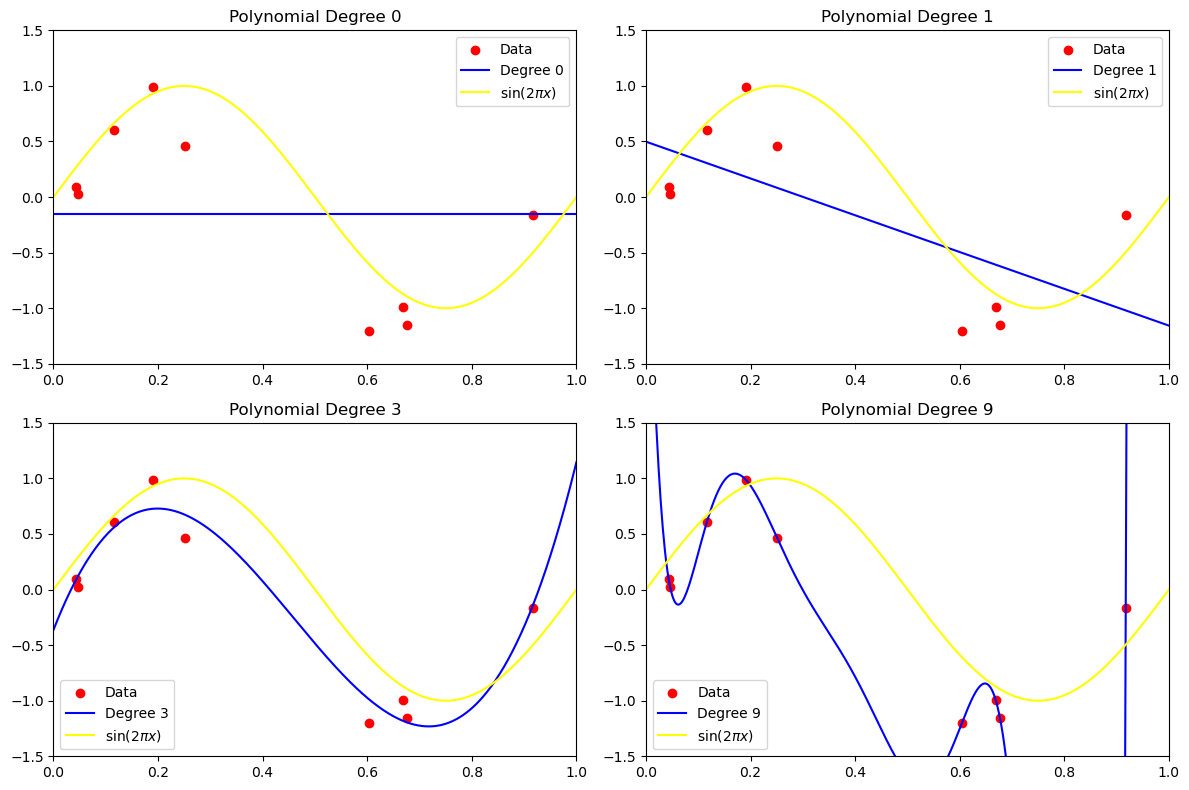

In [37]:
degrees = [0, 1, 3, 9]

# Grid for plotting model predictions
X_plot = np.linspace(0, 1, 500).reshape(-1, 1)

# Set up 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Flatten to easily iterate

for i, degree in enumerate(degrees):
    # Fit model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1, 1), t)

    # Predict
    y_pred = model.predict(X_plot)

    # Plot
    axes[i].scatter(x, t, color='red', label='Data')
    axes[i].plot(X_plot, y_pred, color='blue', label=f'Degree {degree}')
    axes[i].plot(X_plot, np.sin(2 * np.pi * X_plot), color='yellow', label=r'$\sin(2\pi x)$')
    axes[i].set_title(f"Polynomial Degree {degree}")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(-1.5, 1.5)
    axes[i].legend()

plt.tight_layout()
plt.show()

The goal is to achieve good generalization by making accurate predictions for new data, which can be done by considering a separate test set comprising 100 data points generated using exactly the same procedure used to generate the training set points but with new choices for the random noise values included in the target values. We evaluate the so-called Root Mean Squared Error:
$$ E_{RMS} = \sqrt{ 2\frac{E(\mathbf{w}^*)}{N}  } $$

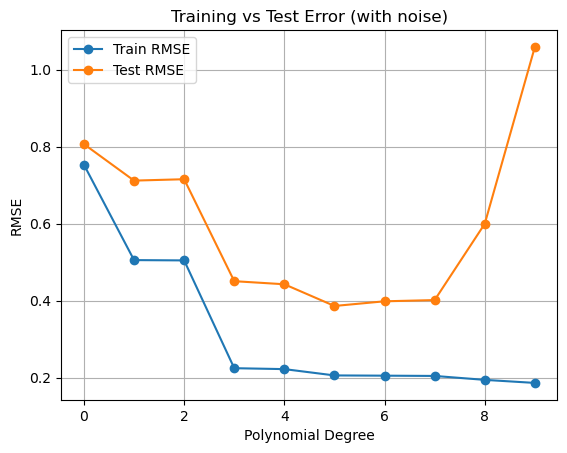

In [8]:
# Train and test error comparison

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(84)
x = np.linspace(0, 1, 30)
t = np.sin(2 * np.pi * x) + 0.3 * np.random.randn(30)

x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=0)
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

train_errors = []
test_errors = []

degrees = range(10)
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train, t_train)
    
    t_train_pred = model.predict(x_train)
    t_test_pred = model.predict(x_test)
    
    train_rmse = np.sqrt(mean_squared_error(t_train, t_train_pred))
    test_rmse = np.sqrt(mean_squared_error(t_test, t_test_pred))
    
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.plot(degrees, train_errors, label='Train RMSE', marker='o')
plt.plot(degrees, test_errors, label='Test RMSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training vs Test Error (with noise)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Extract coefficients
degrees = [0,1,3,9]

np.random.seed(41)
n = 9
x = np.random.uniform(0, 1, size = n)
t = np.sin(2*np.pi*x) + np.random.normal(0, 0.3, size = n)

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1,1), t)
    linear_reg = model.named_steps['linearregression']
    print("Intercept:", linear_reg.intercept_)
    print("Coefficients:", linear_reg.coef_)

Intercept: -0.1480716196893047
Coefficients: [0.]
Intercept: 0.4981912503392558
Coefficients: [ 0.         -1.65496781]
Intercept: -0.3631705081782949
Coefficients: [  0.          12.07452804 -38.70688947  28.14231905]
Intercept: 4.252342909305283
Coefficients: [ 1.99425231e-05 -1.92016780e+02  2.99017826e+03 -2.08170513e+04
  7.49195065e+04 -1.40988481e+05  1.09558648e+05  4.15753839e+04
 -1.21967077e+05  5.52296643e+04]


In [46]:
# Reducing overfit by getting more data

np.random.seed(41)
n_1 = 15
x_1 = np.random.uniform(0, 1, size = n_1)
t_1 = np.sin(2*np.pi*x_1) + np.random.normal(0, 0.3, size = n_1)

n_2 = 100
x_2 = np.random.uniform(0, 1, size = n_2)
t_2 = np.sin(2*np.pi*x_2) + np.random.normal(0, 0.3, size = n_2)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degree = 9

# Fit model for N = 15 and 100
model1 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model1.fit(x_1.reshape(-1,1), t_1)

model2 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model2.fit(x_2.reshape(-1,1), t_2)

# Predictions
X_plot = np.linspace(0, 1, 200).reshape(-1,1)

y_1_pred = model1.predict(X_plot)
y_2_pred = model2.predict(X_plot)

We  see that increasing the size of the data set reduces the over-fitting problem, comparing $N = 15$  with $N = 100$.

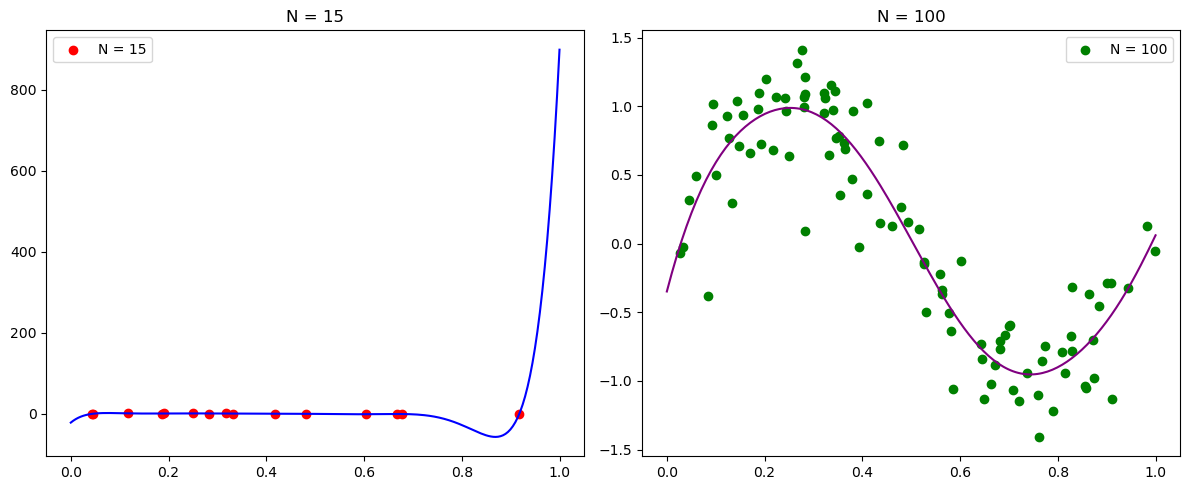

In [50]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# N = 15
axes[0].scatter(x_1, t_1, color='red', label='N = 15')
axes[0].plot(X_plot, y_1_pred, color='blue')
axes[0].set_title('N = 15')
axes[0].legend()

# N = 100
axes[1].scatter(x_2, t_2, color='green', label='N = 100')
axes[1].plot(X_plot, y_2_pred, color='purple')
axes[1].set_title('N = 100')
axes[1].legend()

plt.tight_layout()
plt.show()


In [11]:
# Ridge regression

np.random.seed(41)
n = 9
x = np.random.uniform(0, 1, size = n)
t = np.sin(2*np.pi*x) + np.random.normal(0, 0.3, size = n)

lam = [np.exp(-18), 1]
degree = 9

Sometimes we may be interested in reducing the complexity of the model, and/or avoiding the overfitting problem arising by considering too many predictors. This can be done through regularization, which involves adding a penalty term to the error function in order to discourage the coefficients from reaching large values:
$$ \tilde{E}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N [y(x_n,\mathbf{w}) - t_n]^2 + \frac{\lambda}{2} \Vert \mathbf{w}\Vert^2  $$
where $\Vert \mathbf{w} \Vert = \mathbf{w}^\top \mathbf{w} = w_0^2+\dots+ w_M^2$ and the coefficient $\lambda$ governs the relative importance of the regularization term compared with the sum-of-squared error terms.

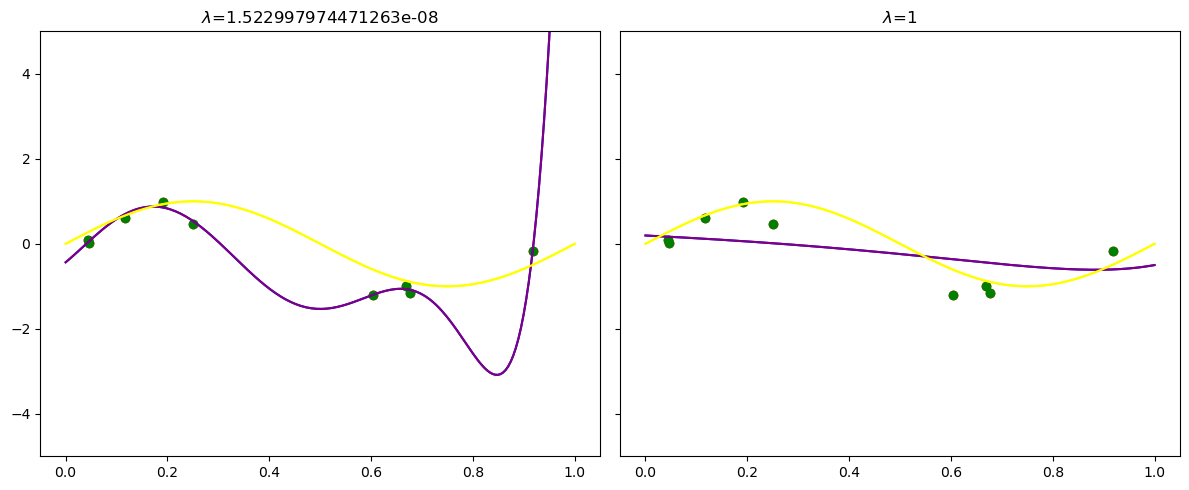

In [12]:
from sklearn.linear_model import Ridge

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, lmbd in enumerate(lam):
    # ln lam = -18
    model1 = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=lmbd))
    model1.fit(x.reshape(-1,1), t)
    y1_pred = model1.predict(X_plot)

    axes[i].scatter(x, t, color='red')
    axes[i].plot(X_plot, y1_pred, color='blue', label=rf'$\lambda$={lmbd}')
    axes[i].plot(X_plot, np.sin(2*np.pi*X_plot), color = 'yellow')
    axes[i].set_title(rf'$\lambda$={lmbd}')
    axes[i].set_ylim(-5, 5)

    # ln lam = 0
    model2 = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=lmbd))
    model2.fit(x.reshape(-1,1), t)
    y2_pred = model2.predict(X_plot)

    axes[i].scatter(x, t, color='green')
    axes[i].plot(X_plot, y2_pred, color='purple', label=rf'$\lambda$={lmbd}')
    axes[i].plot(X_plot, np.sin(2*np.pi*X_plot), color = 'yellow')
    axes[i].set_title(rf'$\lambda$={lmbd}')
    axes[i].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

In [13]:
# Extract coefficients for ridge regression
degree = 9
lam = [0,np.exp(-18), 1]

np.random.seed(41)
n = 9
x = np.random.uniform(0, 1, size = n)
t = np.sin(2*np.pi*x) + np.random.normal(0, 0.3, size = n)

for i, lmbd in enumerate(lam):
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=lmbd))
    model.fit(x.reshape(-1,1), t)
    linear_reg = model.named_steps['ridge']
    print("Intercept:", linear_reg.intercept_)
    print("Coefficients:", linear_reg.coef_)

Intercept: 4.2564335931947275
Coefficients: [      0.            -192.21134839    2993.29642085  -20840.39518247
   75009.14104951 -141162.09406335  109691.75523522   41629.44780074
 -122112.3102836    55292.34229846]
Intercept: -0.43462486713668425
Coefficients: [   0.            9.90011507   34.92611761 -376.75357915  539.59307426
  198.86037114 -315.5080856  -405.96331675  -92.84560566  430.04906073]
Intercept: 0.19544230319813077
Coefficients: [ 0.         -0.60614434 -0.43239807 -0.21073087 -0.05228466  0.04755731
  0.10648451  0.13875457  0.15410596  0.15890766]


c:\Users\almar\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:250: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


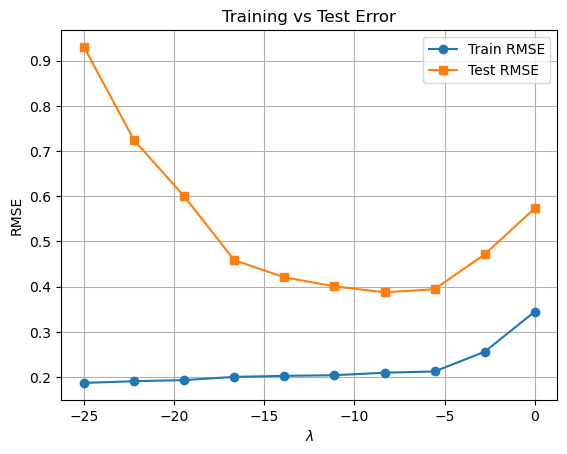

In [15]:
# Train and test error comparison for ridge regression
from sklearn.preprocessing import StandardScaler

np.random.seed(84)
x = np.linspace(0, 1, 30)
t = np.sin(2 * np.pi * x) + 0.3 * np.random.randn(30)

x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=0)
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

train_errors = []
test_errors = []

ln_lam = np.linspace(-25, 0, 10)
lam = np.exp(ln_lam)
degree = 9

for lmbd in lam:
    model = make_pipeline(
        PolynomialFeatures(degree), 
        StandardScaler(), 
        Ridge(alpha=lmbd)
    )
    model.fit(x_train, t_train)
    
    t_train_pred = model.predict(x_train)
    t_test_pred = model.predict(x_test)
    
    train_rmse = np.sqrt(mean_squared_error(t_train, t_train_pred))
    test_rmse = np.sqrt(mean_squared_error(t_test, t_test_pred))
    
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.plot(ln_lam, train_errors, label='Train RMSE', marker='o')
plt.plot(ln_lam, test_errors, label='Test RMSE', marker='s')
plt.xlabel(rf'$\lambda$')
plt.ylabel('RMSE')
plt.title('Training vs Test Error')
plt.legend()
plt.grid(True)
plt.show()


We introduce a Bayesian treatment for the curve fitting problem: consider $t_n \sim \mathcal{N}(y(x_n,\mathbf{w}), \beta^{-1})$ with $\mathbf{w} \sim \mathcal{N}(0,\alpha^{-1}\mathbf{I})$, then the posterior distribution for the model is $p(\mathbf{w}\mid\mathbf{x}, \mathbf{t}, \alpha, \beta) \propto p(\mathbf{t}\mid \mathbf{x}, \mathbf{w}\beta) p (\mathbf{w})$, i.e.
$$ -\frac{1}{2}[ \beta (\mathbf{t} - \mathbf{Xw})^\top(\mathbf{t}- \mathbf{Xw}) + \alpha \mathbf{w}^\top \mathbf{w}] = - \frac{1}{2}[ \beta \mathbf{t}^\top\mathbf{t} - 2\beta \mathbf{w}^\top \mathbf{X}^\top \mathbf{t} + \beta \mathbf{w}^\top \mathbf{X}^\top \mathbf{Xw} + \alpha \mathbf{w}^\top \mathbf{w} ] $$
We can collect $\alpha \mathbf{I} + \beta \mathbf{X}^\top \mathbf{X}$ for $\mathbf{w}^\top \mathbf{w}$, which gives the (generalized) variance $\mathbf{S}_N$ and get rid of the terms constant with respect to the parameters.
$$ -\frac{1}{2}[\mathbf{w}^\top\mathbf{S}_n \mathbf{w} - 2\mathbf{w}^\top (\beta \mathbf{X}^\top \mathbf{t})] $$
After completing the square it is possible to obtain the posterior distribution $\mathbf{w}\mid \mathbf{x}, \mathbf{t}, \alpha, \beta \sim \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N^{-1})$, with $\mathbf{m}_N =\beta \mathbf{S}_N \mathbf{X}^\top \mathbf{t}$. The predictive distribution for a new observation is given by
$$ p(t\mid x, \mathbf{x}, \mathbf{t}) = \int p(t\mid x, \mathbf{w}) p(\mathbf{w}\mid\mathbf{x},\mathbf{t})\, d\mathbf{w} $$
One can derive the result exploiting the knwon distributions aiming to obtain another known kernel (hint: expect a Gaussian); in this case the integral has a famous form which results in another Gaussian. We get that $t \mid x, \mathbf{x}, \mathbf{t} \sim \mathcal{N}(m(x),s^2(x))$, where
$$ m(x) = \phi(x)^\top \mathbf{m}_N = \phi(x)^\top \beta \mathbf{S}_N \mathbf{X}^\top \mathbf{t} = \beta \phi(x)^\top \mathbf{S}_N \sum_{n=1}^N \phi(x_n) t_n $$
and
$$ s^2(x) = \mathbb{V}[\phi(x)^\top \mathbf{w}\mid \mathbf{x},\mathbf{t}] + \mathbb{V}[t|\mathbf{x},\mathbf{w},\beta] = \phi(x)^\top \mathbf{S}_N \phi(x) + \beta^{-1} $$

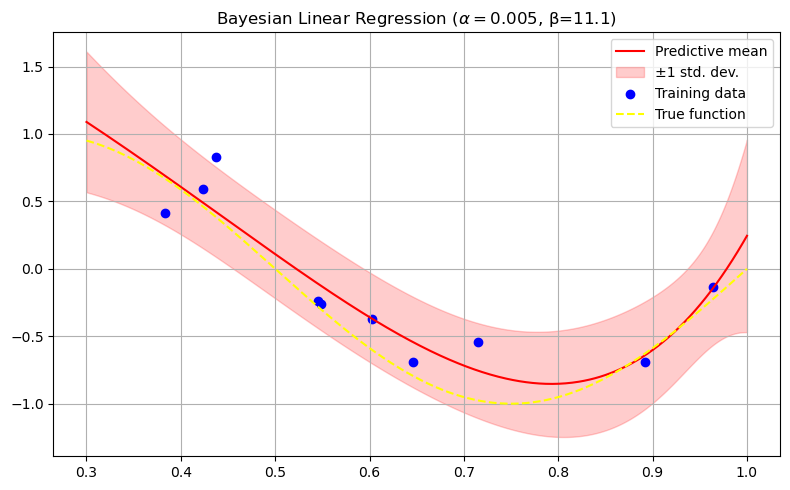

In [ ]:
# Bayesian curve fitting

import numpy as np
import matplotlib.pyplot as plt

degree = 9
alpha = 5e-3
beta = 11.1

np.random.seed(0)
n = 10
x_train = np.random.uniform(0, 1, n)
t_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.3, n)

# Basis function (polynomial)
def phi(x, degree):
    return np.array([x**d for d in range(degree + 1)]).T

# Design matrix for training data
Phi = phi(x_train, degree)  # (N, M)
M = Phi.shape[1]

# Compute S (posterior covariance of weights)
S_inv = alpha * np.eye(M) + beta * Phi.T @ Phi
S = np.linalg.inv(S_inv)

# Compute m(x) and s^2(x) over prediction inputs
x_plot = np.linspace(0.3, 1, 500)
Phi_plot = phi(x_plot, degree)  #(len(x_plot), M)

# Compute posterior mean of weights
w_mean = beta * S @ Phi.T @ t_train  #(M,)

# Predictive mean
m_x = Phi_plot @ w_mean  #(len(x_plot),)

# Predictive variance
s2_x = 1 / beta + np.sum(Phi_plot @ S * Phi_plot, axis=1)  #(len(x_plot),)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_plot, m_x, label="Predictive mean", color='red')
plt.fill_between(x_plot, m_x - np.sqrt(s2_x), m_x + np.sqrt(s2_x), color='red', alpha=0.2, label="±1 std. dev.")
plt.scatter(x_train, t_train, color='blue', label="Training data")
plt.plot(x_plot, np.sin(2 * np.pi * x_plot), color='yellow', linestyle='--', label="True function")
plt.title(r"Bayesian Linear Regression ($\alpha=$"+f"{alpha}, β={beta})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
